Converged at episode 3036


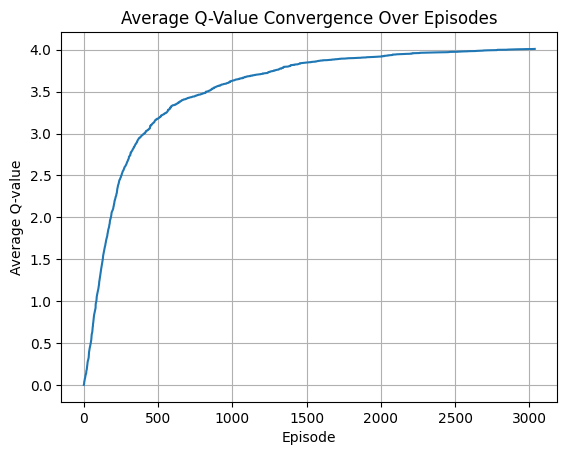

State (0, 0, 0, 0, 0): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 0, 0, 1): Preferred Action (0, 1, 0, 0, 0, 0, 0, 0, 1, 0)
State (0, 0, 0, 0, 2): Preferred Action (0, 1, 0, 0, 0, 0, 0, 0, 1, 0)
State (0, 0, 0, 1, 0): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 0, 1, 1): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 0, 2, 0): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 0, 2, 1): Preferred Action (0, 0, 0, 1, 0, 0, 1, 0, 0, 0)
State (0, 0, 0, 3, 0): Preferred Action (0, 0, 0, 0, 1, 0, 0, 0, 1, 0)
State (0, 0, 0, 4, 0): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 1, 0, 0): Preferred Action (0, 0, 0, 0, 0, 0, 0, 0, 1, 1)
State (0, 0, 1, 0, 1): Preferred Action (0, 0, 0, 1, 1, 0, 0, 0, 0, 0)
State (0, 0, 1, 0, 2): Preferred Action (0, 1, 0, 0, 0, 0, 0, 1, 0, 0)
State (0, 0, 1, 1, 0): Preferred Action (0, 1, 0, 0, 0, 1, 0, 0, 0, 0)
State (0, 0, 1, 1, 1): Preferred Action (0, 1, 0, 0, 0, 0, 0, 0, 1, 0)
State 

In [ ]:
import itertools
import numpy as np
import random
import matplotlib.pyplot as plt

# Resource constraints
resources_c1 = 0.5
resources_c2 = 0.4
resources_c3 = 0.4

# Task resource requirements
k1_resource = 0.1
k2_resource = 0.2

# Arrival rates
lambda_1 = 3.51
lambda_2 = 1.17

# departure rates
mu_1=0.9
mu_2=0.3

# Generate all valid states
valid_states = []
state_indices = {}
index = 0

for S_11, S_12, S_21, S_31, S_32 in itertools.product(
    range(int(resources_c1 / k1_resource) + 1),
    range(int(resources_c1 / k2_resource) + 1),
    range(int(resources_c2 / k1_resource) + 1),
    range(int(resources_c3 / k1_resource) + 1),
    range(int(resources_c3 / k2_resource) + 1),
):
    c1_usage = S_11 * k1_resource + S_12 * k2_resource
    c2_usage = S_21 * k1_resource
    c3_usage = S_31 * k1_resource + S_32 * k2_resource

    if c1_usage <= resources_c1 and c2_usage <= resources_c2 and c3_usage <= resources_c3:
        state = (S_11, S_12, S_21, S_31, S_32)
        valid_states.append(state)
        state_indices[state] = index
        index += 1

num_states = len(valid_states)

# Generate all possible actions
def generate_combinations(length):
    array = [0, 1]
    return list(itertools.product(array, repeat=length))

actions_indices = {}
combinations = generate_combinations(10)
possible_actions = []

i = 0
for combination in combinations:
    if (
        combination[0] + combination[2] + combination[3] + combination[5] + combination[7] + combination[8] == 1
        and combination[1] + combination[4] + combination[6] + combination[9] == 1
    ):
        possible_actions.append(combination)
        actions_indices[combination] = i
        i += 1

# Supporting function for resource constraints
def max_resources_per_state():
    """
    Returns the maximum possible allocations for each task type based on resource constraints.
    """
    return [
        int(resources_c1 / k1_resource),  # Max S_11
        int(resources_c1 / k2_resource),  # Max S_12
        int(resources_c2 / k1_resource),  # Max S_21
        int(resources_c3 / k1_resource),  # Max S_31
        int(resources_c3 / k2_resource),  # Max S_32
    ]

def simulate_environment(state, action, valid_states, arrival_times, service_times):
    """
    Simulates the environment dynamics and returns the next state and a reward.
    """
    current_state = list(state)

    # Get the current time, which will be the minimum of the arrival or service times
    next_event_time = min(min(arrival_times), min(service_times))

    # Subtract the next_event_time from both arrival_times and service_times to progress time
    arrival_times = [max(0, arrival - next_event_time) for arrival in arrival_times]
    service_times = [max(0, service - next_event_time) for service in service_times]

    # Update arrival times only if the corresponding time reaches zero (i.e., task arrives)
    if arrival_times[0] == 0 and (action[0] or action[2] or action[3]):  # Task type 1
        arrival_times[0] = random.expovariate(lambda_1)  # Generate a new arrival time only when the task arrives
    if arrival_times[1] == 0 and (action[1] or action[4]):  # Task type 2
        arrival_times[1] = random.expovariate(lambda_2)  # Generate a new arrival time only when the task arrives

    # Update service times only if the task is ready for service (i.e., assigned a service time)
    for i in range(len(service_times)):
        if service_times[i] == 0 and current_state[i]:  # Task is ready for service
            service_times[i] = random.expovariate(mu_1 if i in [0, 2, 3] else mu_2)  # Generate service time if not already set


    # Determine the next event (arrival or departure)
    event_type = "arrival" if min(arrival_times) < min(service_times) else "departure"

    # Process the event
    if event_type == "arrival":
        if arrival_times[0] < arrival_times[1]:
          if action[0]==1:
            current_state[0] = min(current_state[0] + 1, max_resources_per_state()[0])
          elif action[2]==1:
            current_state[2] = min(current_state[2] + 1, max_resources_per_state()[2])
          elif action[3]==1:
            current_state[3] = min(current_state[3] + 1, max_resources_per_state()[3])
        elif action[1]:
            current_state[1] = min(current_state[1] + 1, max_resources_per_state()[1])
        elif action[4]:
            current_state[4] = min(current_state[4] + 1, max_resources_per_state()[4])
    else:  # Departure
        departure_index = service_times.index(min(service_times))
        current_state[departure_index] = max(0, current_state[departure_index] - 1)

    # Ensure the new state is valid
    max_resources = max_resources_per_state()
    new_state = tuple(min(x, y) for x, y in zip(current_state, max_resources))

    # Find the next state index
    if new_state in state_indices:
        next_state_idx = state_indices[new_state]
    else:
        next_state_idx = state_indices[random.choice(valid_states)]
        return next_state_idx, -1,next_event_time, arrival_times, service_times

    # Calculate the reward
    reward = dynamic_reward_system(new_state, action)

    return next_state_idx, reward, next_event_time, arrival_times, service_times

def dynamic_reward_system(state, action):
    """
    Calculates the dynamic reward based on the current state.
    """
    S_11, S_12, S_21, S_31, S_32 = state

    # Define thresholds for resource utilization
    max_resources = max_resources_per_state()

    # Calculate utilization ratios
    utilization_c1 = (S_11*k1_resource + S_12*k2_resource) / resources_c1
    utilization_c2 = S_21*k1_resource / resources_c2
    utilization_c3 = (S_31*k1_resource + S_32*k2_resource) / resources_c3

    # Define rewards based on utilization
    reward = 0
    if (action[0]|action[1]):
      if utilization_c1!=0:
         reward+=(resources_c1/(S_11*k1_resource + S_12*k2_resource))*5
      else:
         reward+=resources_c1*5
    elif action[2]:
      if utilization_c2!=0:
         reward+=(resources_c2/S_21*k1_resource)*5
      else:
         reward+=resources_c2*5
    elif (action[3]|action[4]):
      if utilization_c3!=0:
         reward+=(resources_c3/(S_31*k1_resource + S_32*k2_resource))*5
      else:
         reward+=resources_c3*5
    else:
      reward+=0.1

    return reward



# Q-Learning Implementation
def q_learning_till_convergence(max_episodes, alpha, gamma, epsilon, epsilon_decay, valid_states, possible_actions, threshold):
    num_states = len(valid_states)
    num_actions = len(possible_actions)
    Q_table = np.zeros((num_states, num_actions))
    q_average_values = []  # Store average Q-values over episodes

    prev_Q_table = np.copy(Q_table)
    for episode in range(max_episodes):
        current_state_idx = random.randint(0, num_states - 1)
        total_reward = 0

        arrival_times = [0] * 2  # Assume we have two tasks
        service_times = [0] * 5  # We assume there are 5 possible actions

        for _ in range(110):  # Limit steps per episode
            if random.uniform(0, 1) < epsilon:
                action_idx = random.randint(0, num_actions - 1)  # Explore
            else:
                action_idx = np.argmax(Q_table[current_state_idx])  # Exploit

            next_state_idx, reward, next_event_time, arrival_times, service_times = simulate_environment(
                valid_states[current_state_idx],
                possible_actions[action_idx],
                valid_states,
                arrival_times,
                service_times
            )

            # Q-learning update rule
            best_next_action = np.max(Q_table[next_state_idx])
            Q_table[current_state_idx, action_idx] += alpha * (
                reward + gamma * best_next_action - Q_table[current_state_idx, action_idx]
            )

            total_reward += reward
            current_state_idx = next_state_idx

        # Compute average Q-value and track it
        average_q_value = np.mean(Q_table)
        q_average_values.append(average_q_value)
        epsilon *= epsilon_decay

        # Convergence check
        if np.max(np.abs(Q_table - prev_Q_table)) < threshold:
            print(f"Converged at episode {episode}")
            break

        prev_Q_table = np.copy(Q_table)

    return Q_table, q_average_values

# Plotting Convergence
def plot_convergence(q_average_values):
    plt.plot(q_average_values)
    plt.title("Average Q-Value Convergence Over Episodes")
    plt.xlabel("Episode")
    plt.ylabel("Average Q-value")
    plt.grid()
    plt.show()

# Simulation Parameters
max_episodes = 10000
alpha = 0.1 #Learning rate
gamma = 0.9
epsilon = 1.0 #exploration rate
epsilon_decay = 0.99
threshold = 1e-5

# Run Q-learning
Q_table, q_average_values = q_learning_till_convergence(
    max_episodes, alpha, gamma, epsilon, epsilon_decay, valid_states, possible_actions, threshold
)
plot_convergence(q_average_values)

def extract_policy(Q_table, valid_states, possible_actions):
    """
    Extracts the optimal policy based on the Q-table.

    Parameters:
        Q_table (numpy.ndarray): The Q-table.
        valid_states (list): List of all valid states.
        possible_actions (list): List of all possible actions.

    Returns:
        policy (dict): A dictionary mapping each state to its preferred action.
    """
    policy = {}
    for state_idx, state in enumerate(valid_states):
        # Find the action with the highest Q-value for the given state
        best_action_idx = np.argmax(Q_table[state_idx])
        best_action = possible_actions[best_action_idx]
        policy[state] = best_action

    return policy

# Extract the policy
policy = extract_policy(Q_table, valid_states, possible_actions)

# Display the policy for inspection
for state, action in policy.items():
    print(f"State {state}: Preferred Action {action}")

